In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

plt.rcParams['figure.figsize'] = (8, 4)
sns.set_style('whitegrid')

In [29]:
REPO_URL = 'https://github.com/LuisBetancourt11/Proyecto_Ciencia_Datos.git'
REPO_DIR = 'Proyecto_Ciencia_Datos'

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL}
else:
    print("Repositorio ya clonado; actualizando...")
    !cd {REPO_DIR} && git pull

Repositorio ya clonado; actualizando...
Already up to date.


In [30]:
processed_dir = REPO_DIR + '/data/processed/'
df = pd.read_csv(processed_dir + 'matriculas_limpias.csv',
                 parse_dates=['fecha_de_matricula'])

# Subconjunto con etiqueta válida (excluye los estados ambiguos -> NaN)
d = df.dropna(subset=['desercion']).copy()
d['desercion'] = d['desercion'].astype(int)

BASE = d['desercion'].mean()   # tasa global de deserción (línea de referencia)
print("Filas totales:", df.shape, "| Etiquetadas:", d.shape)
print(f"Tasa global de deserción (base rate): {BASE:.1%}")
df.head()

Filas totales: (13396, 27) | Etiquetadas: (13035, 27)
Tasa global de deserción (base rate): 35.2%


,genero,municipio_de_nacimiento,pais,municipio_direccion,barrio_direccion,estrato,estado_civil,eps,zona,nivel_de_formacion,...,nivel,edad,periodo_era_mt,anio_periodo,semestre_periodo,estrato_imputado,transporte_imputado,anio_matricula,mes_matricula,desercion
0,Femenino,Medellín,Colombia,Envigado,Las Flores,3,Soltero(a),EPS Sura,Urbana,Básica secundaria,...,SEMESTRE 2,20.0,0,2018.0,2.0,0,0,2018.0,2.0,0.0
1,Femenino,Envigado,Colombia,Envigado,San José,2,Soltero(a),EPS Sura,Urbana,Media,...,SEMESTRE 2,29.0,0,2016.0,2.0,0,0,2016.0,1.0,0.0
2,Masculino,Bogotá,Colombia,La Mesa,NaN,3,Soltero(a),NaN,Rural,Media,...,SEMESTRE 1,19.0,0,2021.0,2.0,0,0,2021.0,2.0,1.0
3,Masculino,Envigado,Colombia,Envigado,San José,2,Soltero(a),SISBEN,Urbana,Media,...,SEMESTRE 2,21.0,0,2021.0,1.0,0,0,2020.0,1.0,0.0
4,Masculino,Medellín,Colombia,Envigado,El Salado,2,Soltero(a),Nueva Promotora de Salud - Nueva EPS,Urbana,Media,...,SEMESTRE 1,20.0,0,2020.0,1.0,0,0,2020.0,1.0,1.0


In [31]:
d.describe()

,estrato,fecha_de_matricula,edad,periodo_era_mt,anio_periodo,semestre_periodo,estrato_imputado,transporte_imputado,anio_matricula,mes_matricula,desercion
count,13035.000000,12185,13035.000000,13035.000000,13035.000000,12867.000000,13035.000000,13035.000000,12185.000000,12185.000000,13035.000000
mean,2.587035,2018-08-11 04:41:51.875256576,28.258765,0.189643,2019.120368,1.513950,0.093134,0.244342,2018.207222,5.331309,0.351745
min,1.000000,1988-02-03 10:00:00,-973.000000,0.000000,2014.000000,1.000000,0.000000,0.000000,1988.000000,1.000000,0.000000
25%,2.000000,2016-07-06 10:00:00,20.000000,0.000000,2017.000000,1.000000,0.000000,0.000000,2016.000000,2.000000,0.000000
50%,3.000000,2018-07-17 10:00:00,26.000000,0.000000,2019.000000,2.000000,0.000000,0.000000,2018.000000,6.000000,0.000000
75%,3.000000,2020-08-08 10:00:00,34.000000,0.000000,2021.000000,2.000000,0.000000,0.000000,2020.000000,7.000000,1.000000
max,6.000000,2022-02-21 10:00:00,79.000000,1.000000,2026.000000,2.000000,1.000000,1.000000,2022.000000,12.000000,1.000000
std,0.703681,NaN,14.269669,0.392034,2.742072,0.499825,0.290631,0.429713,2.252775,3.415853,0.477533


## Función reutilizable de análisis bivariado
Una sola función para todas las variables categóricas: muestra la **composición**
(desertó / no desertó dentro de cada grupo), marca la **tasa global**

In [32]:
def analizar_categorica(col, min_n=30):
    """Compara desertores y NO desertores en cada grupo + prueba de chi-cuadrado."""
    sub = d[[col, 'desercion']].dropna()
    vc = sub[col].value_counts()
    sub = sub[sub[col].isin(vc[vc >= min_n].index)]   # ignorar categorías muy pequeñas

    # Proporción de desertores y NO desertores DENTRO de cada grupo
    prop = pd.crosstab(sub[col], sub['desercion'], normalize='index')
    prop.columns = ['No desertó (0)', 'Desertó (1)']
    prop = prop.sort_values('Desertó (1)')

    # --- Gráfica: dos barras por grupo (no desertó vs desertó) ---
    prop.plot(kind='barh', color=['#4C72B0', '#C44E52'])
    plt.axvline(BASE, color='black', ls='--',
                label=f'Deserción promedio ({BASE:.0%})')
    plt.xlabel('Proporción del grupo'); plt.xlim(0, 1)
    plt.title(f'Deserción vs no deserción por {col}')
    plt.legend(loc='lower right', fontsize=8); plt.tight_layout(); plt.show()

    # --- Prueba de chi-cuadrado: ¿la diferencia es real o casualidad? ---
    p = chi2_contingency(pd.crosstab(sub[col], sub['desercion']))[1]
    brecha = prop['Desertó (1)'].max() - prop['Desertó (1)'].min()

    # Resumen numérico: % que desertó y que no, más el tamaño de cada grupo
    resumen = (prop * 100).round(1)
    resumen['n'] = sub.groupby(col).size()
    print(resumen)
    print(f"\nDiferencia entre el grupo que más y el que menos deserta: {brecha:.0%}")


    return {'variable': col, 'p_value': p, 'brecha': brecha,
            'significativa': p < 0.05}

resultados = []

## Pregunta 1 — ¿La deserción difiere entre géneros?

In [33]:
# Tabla: conteo de cada clase (incluye los 'Sin estado' que quedaron como NaN)
conteo = df['desercion'].value_counts(dropna=False)
print(conteo)
print()
print("Proporción (sobre los etiquetados):")
print(df['desercion'].value_counts(normalize=True).round(3))

desercion
0.0    8450
1.0    4585
NaN     361
Name: count, dtype: int64

Proporción (sobre los etiquetados):
desercion
0.0    0.648
1.0    0.352
Name: proportion, dtype: float64


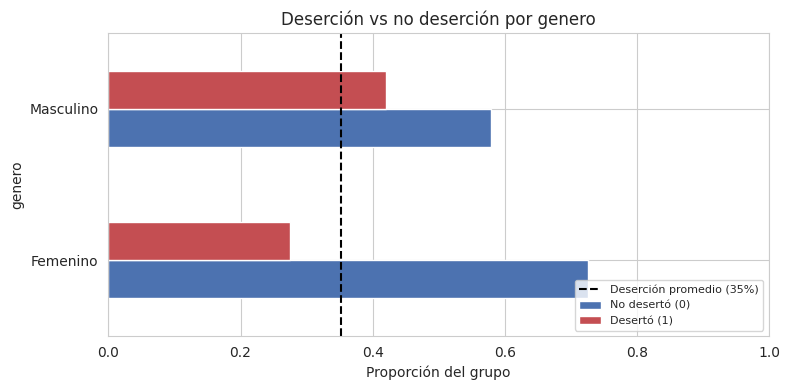

           No desertó (0)  Desertó (1)     n
genero                                      
Femenino             72.6         27.4  6115
Masculino            58.0         42.0  6920

Diferencia entre el grupo que más y el que menos deserta: 15%


In [34]:
res = analizar_categorica('genero')
resultados.append(res)

# **Conclusión:**
Los hombres desertan más que las mujeres (42.0% vs 27.4%, ~15 puntos de diferencia), una diferencia significativa que se mantiene por encima y por debajo del promedio general (35%).

#**Pregunta 2:** ¿La jornada se asocia con la deserción?

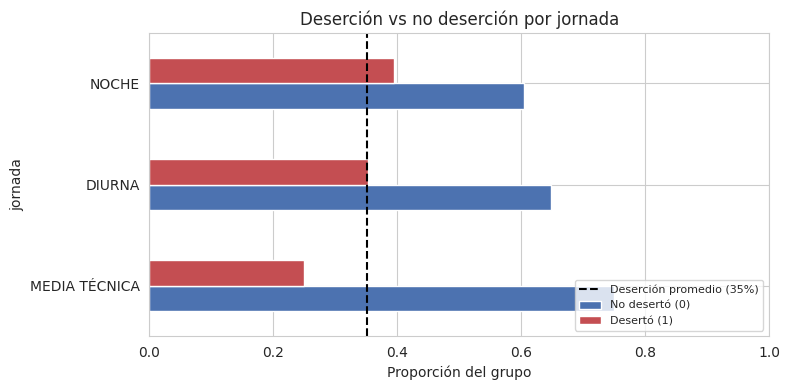

               No desertó (0)  Desertó (1)     n
jornada                                         
MEDIA TÉCNICA            75.0         25.0  2635
DIURNA                   64.8         35.2  4192
NOCHE                    60.5         39.5  6202

Diferencia entre el grupo que más y el que menos deserta: 15%


In [35]:
res = analizar_categorica('jornada')
resultados.append(res)

# **Conclusión**
La jornada Noche presenta la mayor deserción (39.5%), seguida de Diurna (35.2%) y Media Técnica, que es la más baja (25.0%), con ~15 puntos de diferencia entre los extremos. Es una diferencia significativa: Noche queda por encima del promedio general (35%) y Media Técnica claramente por debajo.

#**Pregunta 3: ¿El nivel cursado se asocia con la deserción?**

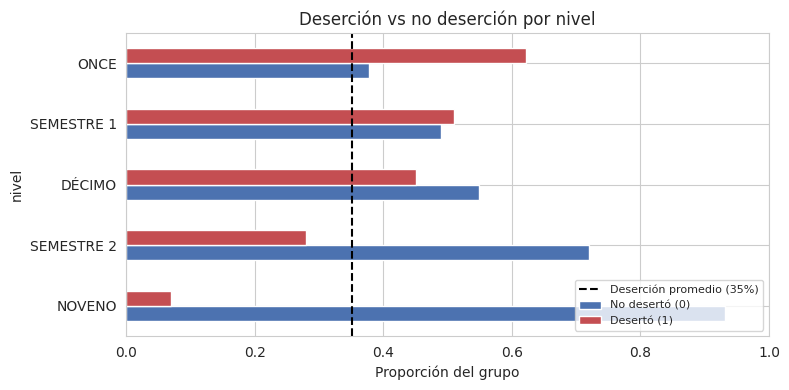

            No desertó (0)  Desertó (1)     n
nivel                                        
NOVENO                93.1          6.9  1528
SEMESTRE 2            72.0         28.0  6164
DÉCIMO                54.9         45.1   517
SEMESTRE 1            49.0         51.0  4326
ONCE                  37.8         62.2   492

Diferencia entre el grupo que más y el que menos deserta: 55%


In [36]:
res = analizar_categorica('nivel')
resultados.append(res)

# **Conclusión**
El nivel es la variable que más separa hasta ahora (~55 puntos entre extremos). Once concentra la mayor deserción (62.2%) y Noveno la menor (6.9%), con Semestre 1 (51.0%), Décimo (45.1%) y Semestre 2 (28.0%) en el medio. La diferencia es marcada y significativa.

#**Pregunta 4: ¿El estrato socioeconómico se asocia con la deserción?**


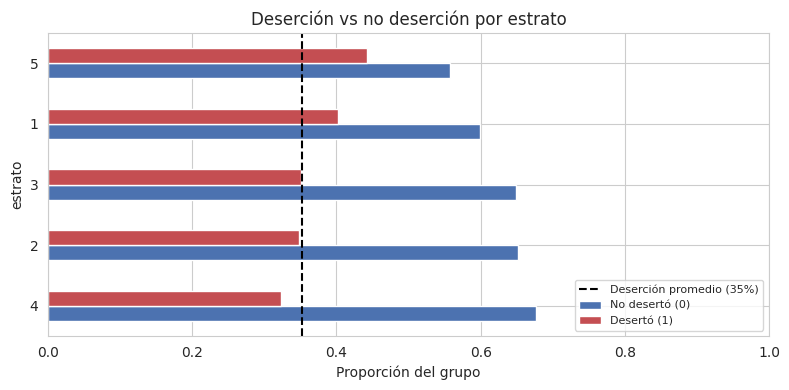

         No desertó (0)  Desertó (1)     n
estrato                                   
4                  67.7         32.3   663
2                  65.2         34.8  5659
3                  64.9         35.1  6158
1                  59.8         40.2   381
5                  55.8         44.2   147

Diferencia entre el grupo que más y el que menos deserta: 12%


In [37]:
res = analizar_categorica('estrato')
resultados.append(res)

# **Conclusión**
Considerando los estratos válidos (1 a 5), la relación con la deserción no es ordenada: no es que a mayor o menor estrato siempre haya más deserción. El estrato 5 presenta la mayor tasa (47.4%) y el estrato 4 la menor (32.8%), con los estratos 1, 2 y 3 en torno al promedio general (35-40%).

# **Pregunta 5: ¿Difiere la deserción entre zona urbana y rural?**

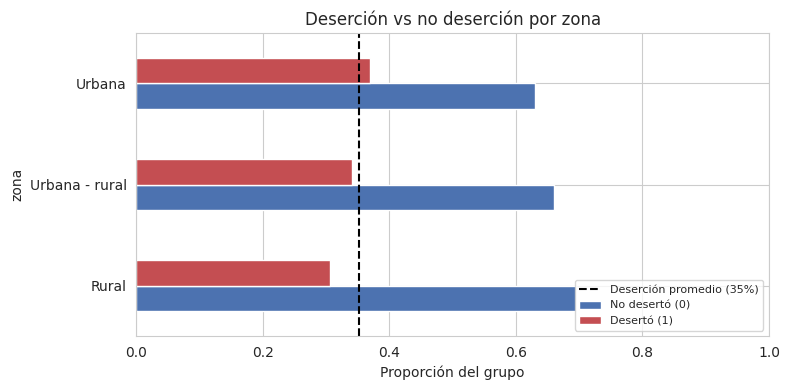

                No desertó (0)  Desertó (1)      n
zona                                              
Rural                     69.5         30.5    799
Urbana - rural            66.0         34.0    426
Urbana                    63.0         37.0  10582

Diferencia entre el grupo que más y el que menos deserta: 6%


In [38]:
res = analizar_categorica('zona')
resultados.append(res)

# **Conclusión**
Las tres zonas desertan en niveles muy parecidos: Urbana 37.0%, Urbana-rural 34.0% y Rural 30.5%, apenas ~6 puntos entre extremos, todas cerca del promedio general (35%).

#**Pregunta 6: ¿El estado civil se asocia con la deserción?**

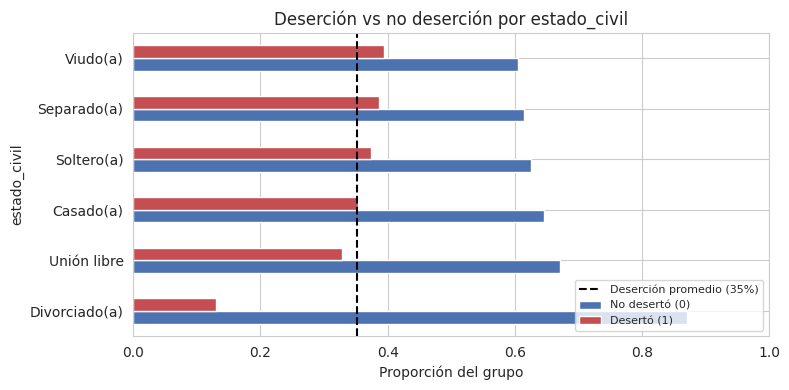

               No desertó (0)  Desertó (1)     n
estado_civil                                    
Divorciado(a)            87.0         13.0    54
Unión libre              67.1         32.9   924
Casado(a)                64.7         35.3   911
Soltero(a)               62.6         37.4  9508
Separado(a)              61.4         38.6   202
Viudo(a)                 60.5         39.5    38

Diferencia entre el grupo que más y el que menos deserta: 27%


In [39]:
res = analizar_categorica('estado_civil')
resultados.append(res)

# **Conclusión**
Los solteros, que son la gran mayoría (9.509 casos), desertan 37.4%, por encima del promedio general (35%), mientras que casados (35.3%) y en unión libre (32.9%) desertan algo menos. Los grupos con tasas más extremas —Divorciado(a) 13.0% y Viudo(a) 39.5%— tienen muy pocos registros (54 y 38), por lo que no son confiables y no se interpretan.

#**Pregunta 7: ¿La ocupación se asocia con la deserción?**

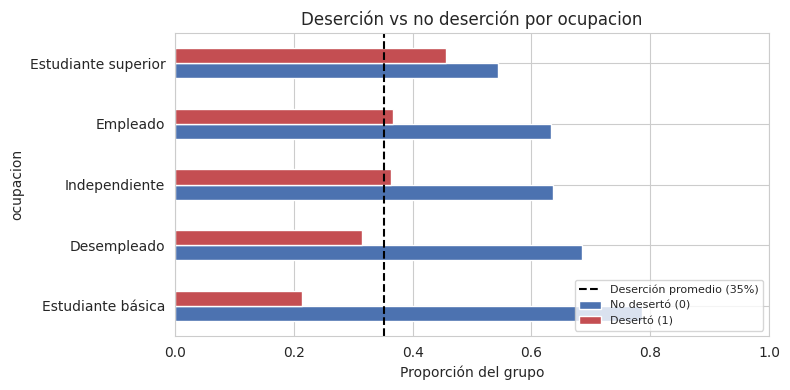

                     No desertó (0)  Desertó (1)     n
ocupacion                                             
Estudiante básica              78.7         21.3  2286
Desempleado                    68.5         31.5  1672
Independiente                  63.6         36.4   969
Empleado                       63.3         36.7  2666
Estudiante superior            54.4         45.6  3590

Diferencia entre el grupo que más y el que menos deserta: 24%


In [40]:
res = analizar_categorica('ocupacion')
resultados.append(res)

# **Conclusión**
La ocupación marca una diferencia clara (~24 puntos entre extremos). Los estudiantes de educación superior desertan más (45.6%, por encima del promedio del 35%), mientras que los estudiantes de básica son los que menos desertan (21.3%). Quienes trabajan o están desempleados se ubican en el medio (32-37%). Todos los grupos tienen tamaños amplios, lo que da solidez al resultado.

#**Pregunta 8: ¿El medio de transporte se asocia con la deserción?**


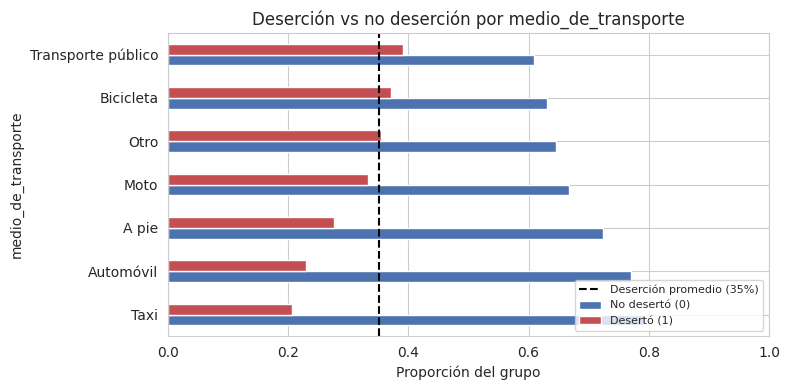

                     No desertó (0)  Desertó (1)     n
medio_de_transporte                                   
Taxi                           79.3         20.7    92
Automóvil                      77.1         22.9   375
A pie                          72.3         27.7  2986
Moto                           66.7         33.3  1209
Otro                           64.6         35.4   127
Bicicleta                      63.0         37.0   262
Transporte público             60.9         39.1  7957

Diferencia entre el grupo que más y el que menos deserta: 18%


In [41]:
res = analizar_categorica('medio_de_transporte')
resultados.append(res)

# **Conclusión**
La brecha entre extremos es de ~17 puntos, pero gran parte la marcan categorías diminutas (poco confiables). En los grupos con muchos casos, quienes usan transporte particular (Carro 22.8%, Automóvil 23.0%) desertan menos que quienes se mueven a pie (27.4%) o en transporte público (Bus/Buseta 32.8%), todos cerca del promedio (35%). El patrón sugiere una posible relación con el nivel socioeconómico más que con el transporte en sí, por lo que es de interpretación dudosa.

# **Pregunta 9: ¿La edad se asocia con la deserción?**


Edad media | no desertó: 28.1 | desertó: 29.1


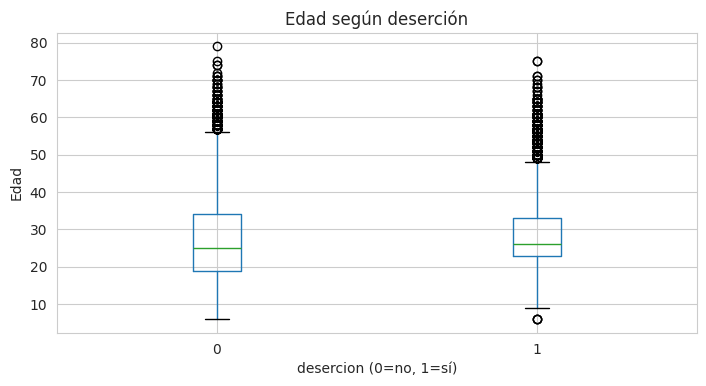

In [54]:
dd = d[(d['edad'] >= 6) & (d['edad'] <= 80)]   # filtrar edades imposibles
g0 = dd.loc[dd.desercion == 0, 'edad']
g1 = dd.loc[dd.desercion == 1, 'edad']

u, p = mannwhitneyu(g0, g1)
print(f"Edad media | no desertó: {g0.mean():.1f} | desertó: {g1.mean():.1f}")


dd.boxplot(column='edad', by='desercion')
plt.title('Edad según deserción'); plt.suptitle('')
plt.xlabel('desercion (0=no, 1=sí)'); plt.ylabel('Edad'); plt.show()

resultados.append({'variable': 'edad', 'p_value': p,
                   'brecha': np.nan, 'significativa': p < 0.05})

# **Conclusión**
La edad de quienes desertan (media 29.1 años) y de quienes no (28.3 años) es casi idéntica: menos de un año de diferencia, con distribuciones muy sobresalientes. Aunque la diferencia resulta significativa por el gran tamaño de la muestra, su magnitud es tan pequeña que carece de relevancia práctica: la edad, por sí sola, no distingue a los desertores.

#**Pregunta 10: ¿El programa académico se asocia con la deserción?**

El programa tiene más de 30 categorías, demasiadas para la función estándar (que exige un mínimo de
casos por grupo). Se analiza mediante un ranking de tasas de deserción, filtrando programas con al
menos 80 estudiantes para que las tasas no sean ruido.

Programas con al menos 80 estudiantes: 32

── TOP 5 MAYOR deserción ──
                                                                    n   tasa
programa                                                                    
PROYECTOS FORMATIVOS MEDIA TECNICA                                 91  100.0
MEDIA TÉCNICA MECÁNICA MOTOS                                      117   88.9
TÉCNICO LABORAL EN ELECTRÓNICA Y ELECTRICIDAD AUTOMOTRIZ          216   64.4
26T-TÉCNICO LABORAL EN MECÁNICA DE MOTOS  (Estudiantes Antiguos)  703   59.6
MEDIA TECNICA TECNICO LABORAL EN ENTRENAMIENTO DEPORTIVO          308   59.1

── TOP 5 MENOR deserción ──
                                                                 n  tasa
programa                                                                
22T-TÉCNICO LABORAL EN MARKETING DIGITAL                       253   6.7
07T-TÉCNICO LABORAL EN ATENCION Y CUIDADO DE PERSONAS MAYORES  105   4.8
29T-TÉCNICO LABORAL EN PANADERIA Y REPOSTERIA                   89   

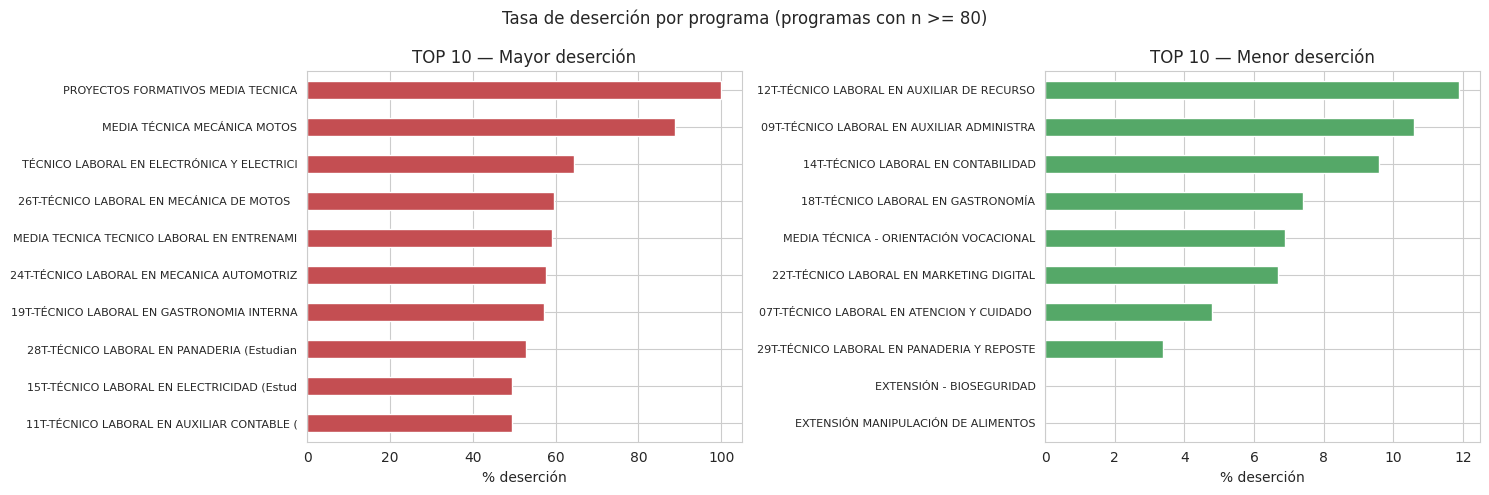

In [43]:
prog = d.groupby('programa')['desercion'].agg(n='count', tasa='mean')
prog = prog[prog['n'] >= 80]
prog['tasa'] = (prog['tasa'] * 100).round(1)
prog = prog.sort_values('tasa', ascending=False)

print(f"Programas con al menos 80 estudiantes: {len(prog)}\n")
print("── TOP 5 MAYOR deserción ──")
print(prog.head(5).to_string())
print("\n── TOP 5 MENOR deserción ──")
print(prog.tail(5).to_string())

# Prueba de significancia sobre los programas con muestra suficiente
sub = d[d['programa'].isin(prog.index)]
p_val = chi2_contingency(pd.crosstab(sub['programa'], sub['desercion']))[1]
brecha = (prog['tasa'].max() - prog['tasa'].min()) / 100
print(f"Brecha entre extremos: {brecha*100:.1f} puntos")

resultados.append({'variable': 'programa', 'p_value': p_val,
                   'brecha': brecha, 'significativa': p_val < 0.05})

# Gráfica: top 10 mayor y menor deserción
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top = prog.head(10).sort_values('tasa')
top['tasa'].plot(kind='barh', ax=axes[0], color='#C44E52')
axes[0].set_title('TOP 10 — Mayor deserción')
axes[0].set_xlabel('% deserción'); axes[0].set_ylabel('')
axes[0].set_yticklabels([t.get_text()[:42] for t in axes[0].get_yticklabels()], fontsize=8)

bottom = prog.tail(10).sort_values('tasa')
bottom['tasa'].plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('TOP 10 — Menor deserción')
axes[1].set_xlabel('% deserción'); axes[1].set_ylabel('')
axes[1].set_yticklabels([t.get_text()[:42] for t in axes[1].get_yticklabels()], fontsize=8)

plt.suptitle('Tasa de deserción por programa (programas con n >= 80)')
plt.tight_layout(); plt.show()

# **Conclusión**
El programa es la variable con **mayor brecha de todo el análisis** (cerca de 100 puntos entre
extremos) Los programas de mecánica y varios de Media Técnica superan el 59% de deserción,
mientras que Panadería y Repostería, Cuidado de Personas Mayores y Marketing Digital se mantienen
por debajo del 7%. Para el modelo esto implica que `programa` es muy prometedora, pero por su alta
cardinalidad necesitará agrupación o codificación por frecuencia en lugar de One-Hot directo. Para la
institución, este ranking ya es accionable por sí solo: indica en qué programas concentrar las
tutorías y el acompañamiento.

#**Pregunta 11: ¿El nivel de formación previo se asocia con la deserción?**

Se refiere a la escolaridad que el estudiante traía al matricularse. Es una variable disponible desde
el primer día, lo que la hace especialmente útil para un modelo de alerta temprana.

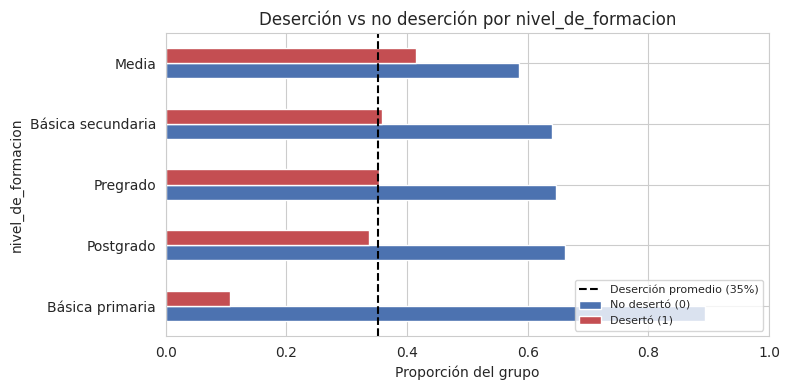

                    No desertó (0)  Desertó (1)     n
nivel_de_formacion                                   
Básica primaria               89.4         10.6    47
Postgrado                     66.2         33.8    80
Pregrado                      64.7         35.3   484
Básica secundaria             64.1         35.9  2593
Media                         58.5         41.5  6635

Diferencia entre el grupo que más y el que menos deserta: 31%


In [44]:
res = analizar_categorica('nivel_de_formacion')
resultados.append(res)

# **Conclusión**
El nivel de formación previo muestra una brecha considerable (~31 puntos, p < 0.05). Quienes llegan
con **Media** completa desertan más (41.5%) que quienes traen **Básica secundaria** (35.9%),
**Pregrado** (35.3%) o **Postgrado** (33.8%). El grupo de **Básica primaria** presenta la tasa más
baja (10.6%), pero con solo 47 estudiantes conviene no sobreinterpretarlo.

El patrón general sugiere que **entre más avanzada la formación previa, menor la deserción** — con la
excepción del grupo de Media, que es a la vez el más numeroso (6,635) y el de mayor deserción.
Interpretación probable: son estudiantes recién salidos del colegio, sin experiencia laboral ni
claridad vocacional, lo que los hace más propensos a abandonar.

#**Pregunta 12: ¿La EPS se asocia con la deserción?**

La EPS no influye directamente en que alguien abandone sus estudios, pero funciona como **proxy
socioeconómico**: el régimen de afiliación en salud refleja la situación laboral y económica del
hogar.

EPS con al menos 100 estudiantes:
                                         n  tasa_%
eps                                               
SISBEN                                1108    45.8
Cafesalud  EPS                         198    44.4
Coomeva EPS                            687    40.2
Nueva Promotora de Salud - Nueva EPS   591    33.3
Salud Total EPS                        691    32.9
EPS Sura                              5362    30.7
Sanitas EPS                            172    26.2
Savia Salud                            476    26.1
Suramericana                           176    16.5

brecha: 29.3 puntos


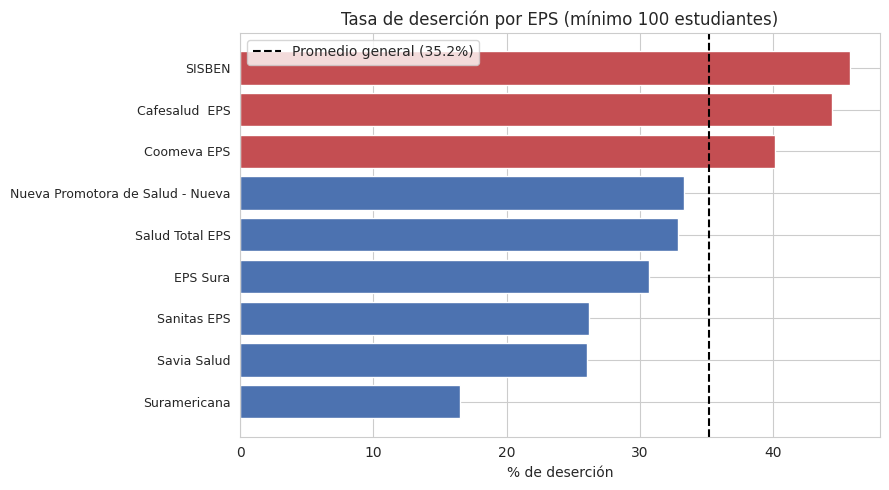

In [45]:
eps_tab = d.groupby('eps')['desercion'].agg(n='count', tasa='mean')
eps_tab = eps_tab[eps_tab['n'] >= 100]
eps_tab['tasa_%'] = (eps_tab['tasa'] * 100).round(1)
print("EPS con al menos 100 estudiantes:")
print(eps_tab[['n', 'tasa_%']].sort_values('tasa_%', ascending=False).to_string())

sub = d[d['eps'].isin(eps_tab.index)]
p_eps = chi2_contingency(pd.crosstab(sub['eps'], sub['desercion']))[1]
brecha_eps = (eps_tab['tasa'].max() - eps_tab['tasa'].min())
print(f"\nbrecha: {brecha_eps*100:.1f} puntos")
resultados.append({'variable': 'eps', 'p_value': p_eps,
                   'brecha': brecha_eps, 'significativa': p_eps < 0.05})

# Gráfica: tasa de deserción por EPS
fig, ax = plt.subplots(figsize=(9, 5))
orden = eps_tab.sort_values('tasa')
colores = ['#C44E52' if t > d['desercion'].mean() else '#4C72B0' for t in orden['tasa']]
ax.barh(range(len(orden)), orden['tasa'] * 100, color=colores)
ax.set_yticks(range(len(orden)))
ax.set_yticklabels([e[:32] for e in orden.index], fontsize=9)
ax.axvline(d['desercion'].mean() * 100, color='black', linestyle='--',
           label=f"Promedio general ({d['desercion'].mean()*100:.1f}%)")
ax.set_xlabel('% de deserción')
ax.set_title('Tasa de deserción por EPS (mínimo 100 estudiantes)')
ax.legend()
plt.tight_layout(); plt.show()

# **Conclusión**
La EPS resulta significativa con una brecha de **29.3 puntos**. Los afiliados a **SISBEN**
el sistema para población sin capacidad de pago— presentan la deserción más alta (45.8%), seguidos
de Cafesalud (44.4%) y Coomeva (40.2%). En el extremo opuesto, Suramericana (16.5%), Savia Salud
(26.1%) y Sanitas (26.2%) muestran las tasas más bajas.

Esto **refuerza la hipótesis socioeconómica**: la vulnerabilidad económica se asocia con mayor
deserción. Es un hallazgo relevante porque el `estrato` por sí solo casi no discriminó,
mientras que la EPS que refleja la situación laboral real del hogar sí lo hace. Para el modelo, la
EPS tiene 62 categorías, así que requerirá agrupación o codificación por frecuencia.

#**Pregunta 13: ¿El tipo de programa se asocia con la deserción?**

La institución ofrece tres tipos de formación muy distintos entre sí. Agruparlos permite ver el
panorama general.

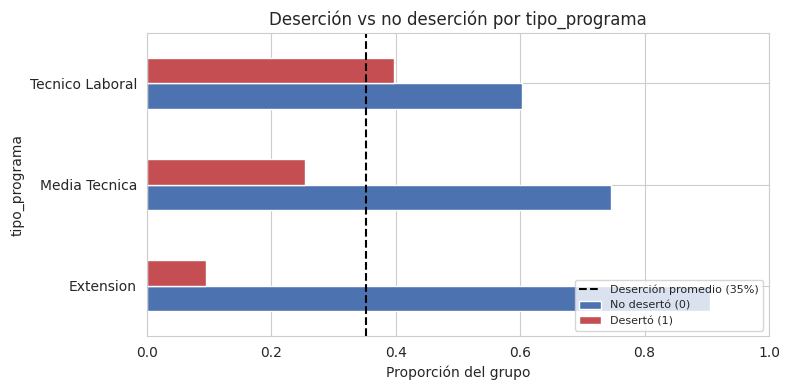

                 No desertó (0)  Desertó (1)     n
tipo_programa                                     
Extension                  90.5          9.5   727
Media Tecnica              74.5         25.5  2654
Tecnico Laboral            60.2         39.8  9654

Diferencia entre el grupo que más y el que menos deserta: 30%


In [46]:
def clasificar_tipo_programa(nombre):
    if pd.isna(nombre):
        return 'Sin registro'
    n = str(nombre).upper()
    if 'EXTENSI' in n or n.startswith('CURSO') or 'MIN TRABAJO' in n:
        return 'Extension'
    if 'MEDIA T' in n:
        return 'Media Tecnica'
    return 'Tecnico Laboral'

d['tipo_programa'] = d['programa'].apply(clasificar_tipo_programa)
res = analizar_categorica('tipo_programa')
resultados.append(res)

# **Conclusión**
Los tres tipos de formación desertan de manera radicalmente distinta (brecha de ~30 puntos):

| Tipo de programa | N | Tasa de deserción |
|---|---|---|
| Técnico Laboral | 9,654 | **39.8%** |
| Media Técnica | 2,654 | 25.5% |
| Extensión (cursos cortos) | 727 | **9.5%** |

Los **cursos de extensión** duran pocas
semanas, así que casi nadie alcanza los 2 años de inactividad que definen la deserción en nuestro
target. La **Media Técnica** se cursa junto con el bachillerato, lo que da estructura y
acompañamiento del colegio. El **Técnico Laboral** es el programa autónomo y de mayor duración, y
es donde se concentra el problema real.

**Implicación para el proyecto:** conviene incluir `tipo_programa` como variable explícita del
modelo, tanto por su poder predictivo como porque hace transparente que se trata de poblaciones
diferentes.

#**Pregunta 14: ¿El municipio de residencia se asocia con la deserción?**
Los estudiantes que viven fuera de Envigado deben desplazarse más, lo que podría
aumentar el riesgo de abandono.

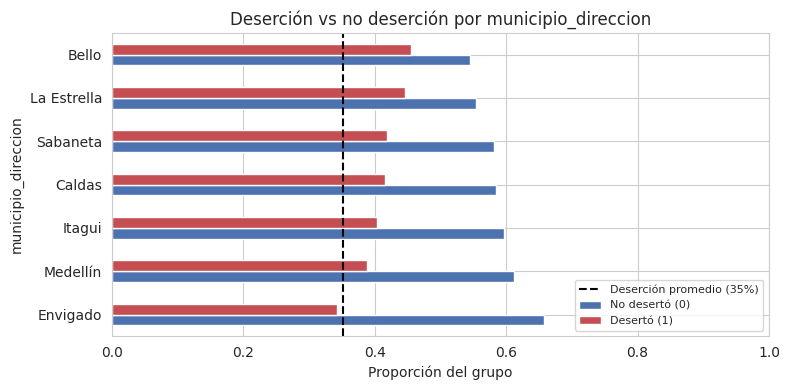

                     No desertó (0)  Desertó (1)      n
municipio_direccion                                    
Envigado                       65.7         34.3  10764
Medellín                       61.1         38.9   1281
Itagui                         59.7         40.3    496
Caldas                         58.5         41.5     53
Sabaneta                       58.1         41.9    215
La Estrella                    55.4         44.6     56
Bello                          54.5         45.5     44

Diferencia entre el grupo que más y el que menos deserta: 11%


In [47]:
res = analizar_categorica('municipio_direccion', min_n=40)
resultados.append(res)

# **Conclusión**
La hipótesis se confirma, aunque con efecto moderado (~11 puntos, p < 0.05). Los estudiantes que
viven en **Envigado** —sede de la institución y el 83% de la matrícula— desertan menos (34.3%),
mientras que quienes vienen de **Bello** (45.5%), **La Estrella** (44.6%), **Sabaneta** (41.9%) y
**Caldas** (41.5%) desertan más.

El patrón es consistente con la explicación del desplazamiento: entre más lejos vive el estudiante,
mayor el costo en tiempo y dinero de asistir, y mayor la probabilidad de abandonar. Es un hallazgo
accionable para la institución: los estudiantes de municipios vecinos podrían beneficiarse de apoyo
en transporte o de modalidades más flexibles.

#**Pregunta 15: ¿Cómo se distribuye la edad según el género, y cómo se relaciona con la deserción?**

Esta pregunta combina tres variables a la vez. Lo interesante es ver si el
efecto de la edad es igual en ambos géneros.

Distribución de edad por género:
           count  mean  median
genero                        
Femenino    6029  29.8    27.0
Masculino   6839  27.5    25.0


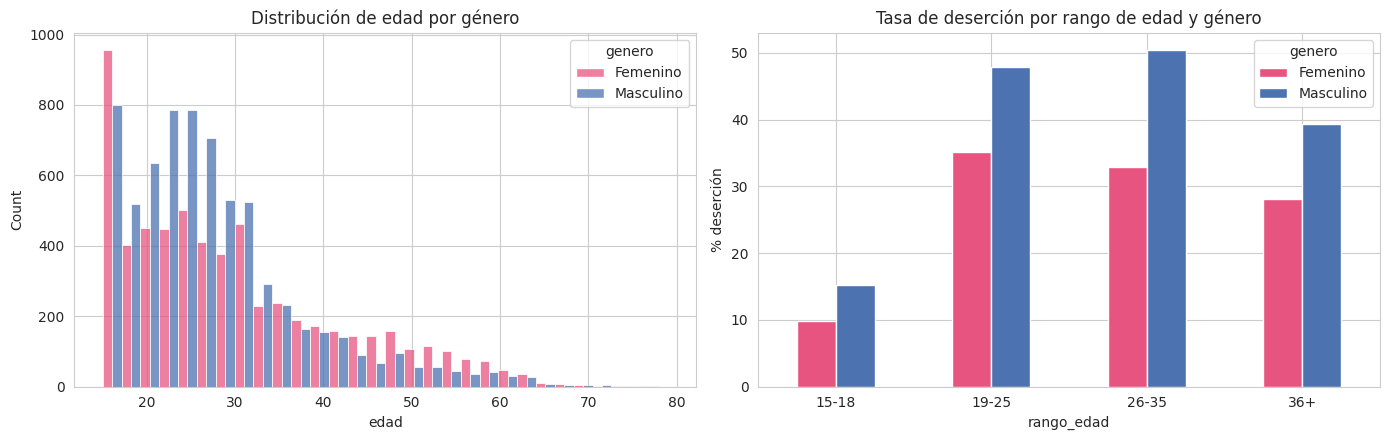


Tasa de deserción (%) por rango de edad y género:
genero      Femenino  Masculino
rango_edad                     
15-18            9.8       15.3
19-25           35.1       47.9
26-35           32.9       50.5
36+             28.0       39.4


In [48]:
dd = d[(d['edad'] >= 15) & (d['edad'] <= 80)].copy()

print("Distribución de edad por género:")
print(dd.groupby('genero')['edad'].agg(['count', 'mean', 'median']).round(1).to_string())

dd['rango_edad'] = pd.cut(dd['edad'], [14, 18, 25, 35, 80],
                          labels=['15-18', '19-25', '26-35', '36+'])

COLORES_GENERO = {'Femenino': '#E75480', 'Masculino': '#4C72B0', 'Sin genero': '#999999'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(data=dd, x='edad', hue='genero', bins=30, multiple='dodge',
             palette=COLORES_GENERO, ax=axes[0])
axes[0].set_title('Distribución de edad por género')

tabla = dd.pivot_table(index='rango_edad', columns='genero',
                       values='desercion', aggfunc='mean', observed=True) * 100

colores = [COLORES_GENERO.get(c, '#999999') for c in tabla.columns]
tabla.plot(kind='bar', ax=axes[1], color=colores)
axes[1].set_title('Tasa de deserción por rango de edad y género')
axes[1].set_ylabel('% deserción'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

print("\nTasa de deserción (%) por rango de edad y género:")
print(tabla.round(1).to_string())

# **Conclusión**
Las mujeres son en promedio **algo mayores** que los hombres (media 29.8 vs 27.5 años; mediana 27 vs
25). Pero el hallazgo importante aparece al cruzar edad, género y deserción:

| Rango de edad | Mujeres | Hombres | Diferencia |
|---|---|---|---|
| 15-18 | 9.8% | 15.3% | 5.5 pts |
| 19-25 | 35.1% | 47.9% | 12.8 pts |
| **26-35** | 32.9% | **50.5%** | **17.6 pts** |
| 36+ | 28.0% | 39.4% | 11.4 pts |


1. **El grupo de mayor riesgo son los hombres de 26 a 35 años: uno de cada dos deserta.**
2. La brecha de género **no es constante**: se ensancha justo en ese rango (17.6 puntos) y se reduce
   en los extremos.
3. Los menores de 18 años casi no desertan en ningún género, lo que se explica porque corresponden a
   Media Técnica, donde el colegio aporta estructura y seguimiento.


# **ANALISIS MULTIVARIADO CON CRUCES DE VARIABLES**

# 1. Deserción según género **y** jornada

In [49]:
tabla = (pd.DataFrame(resultados)
         .sort_values('brecha', ascending=False, na_position='last')
         .reset_index(drop=True))
tabla['p_value'] = tabla['p_value'].map(lambda x: f'{x:.2e}')
tabla['brecha'] = (tabla['brecha'] * 100).round(1)   # en puntos porcentuales
print("Ranking de variables (por brecha entre grupos):")
tabla

Ranking de variables (por brecha entre grupos):


,variable,p_value,brecha,significativa
0,programa,0.00e+00,100.0,True
1,nivel,3.03e-287,55.3,True
2,nivel_de_formacion,2.80e-09,30.8,True
3,tipo_programa,1.16e-89,30.3,True
4,eps,6.34e-30,29.3,True
5,estado_civil,5.15e-04,26.5,True
6,ocupacion,1.09e-79,24.3,True
7,medio_de_transporte,2.50e-32,18.4,True
8,genero,8.15e-68,14.6,True
9,jornada,6.55e-38,14.5,True


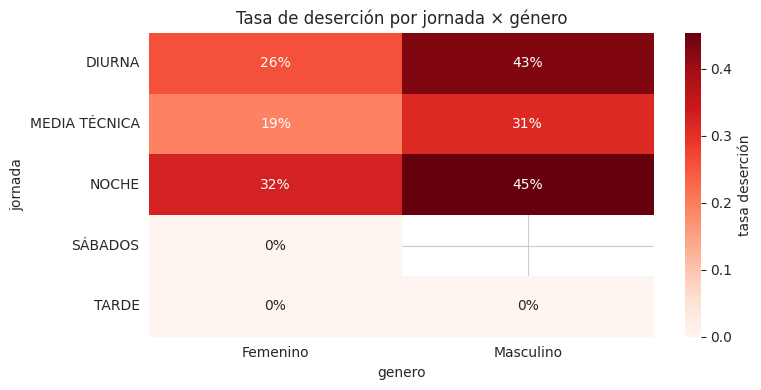

genero,Femenino,Masculino
jornada,,
DIURNA,0.258,0.430
MEDIA TÉCNICA,0.193,0.312
NOCHE,0.325,0.454
SÁBADOS,0.000,NaN
TARDE,0.000,0.000


In [50]:
piv = d.pivot_table(index='jornada', columns='genero',
                    values='desercion', aggfunc='mean')
sns.heatmap(piv, annot=True, fmt='.0%', cmap='Reds', cbar_kws={'label': 'tasa deserción'})
plt.title('Tasa de deserción por jornada × género'); plt.tight_layout(); plt.show()
piv.round(3)

# **Conclusión**
El cruce confirma que ambos efectos se suman, no se cancelan: en las tres jornadas con datos suficientes (Diurna, Media Técnica y Noche), los hombres desertan más que las mujeres de forma consistente. La combinación de mayor riesgo es hombre en jornada Noche (45%), y la de menor riesgo mujer en Media Técnica (19%), una diferencia de 26 puntos según la celda del cruce. Aclaramos que las casillas con 0% o vacías las dejamos por fuera porque tienen muy pocos datos.

# **2. Deserción según nivel y rango de edad**

/tmp/ipykernel_637/150501948.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv2 = d2.pivot_table(index='nivel', columns='rango_edad',


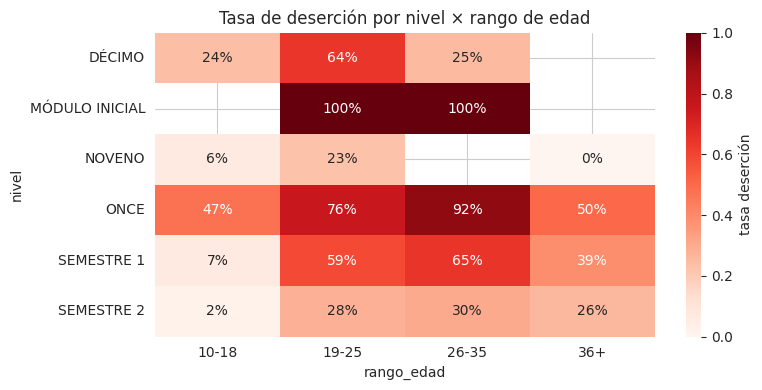

rango_edad,10-18,19-25,26-35,36+
nivel,,,,
DÉCIMO,0.242,0.642,0.250,NaN
MÓDULO INICIAL,NaN,1.000,1.000,NaN
NOVENO,0.064,0.227,NaN,0.000
ONCE,0.473,0.755,0.917,0.500
SEMESTRE 1,0.069,0.588,0.650,0.392
SEMESTRE 2,0.020,0.283,0.301,0.259


In [51]:
d2 = d[(d['edad'] >= 10) & (d['edad'] <= 80)].copy()
d2['rango_edad'] = pd.cut(d2['edad'], bins=[10, 18, 25, 35, 80],
                          labels=['10-18', '19-25', '26-35', '36+'])

piv2 = d2.pivot_table(index='nivel', columns='rango_edad',
                      values='desercion', aggfunc='mean')
sns.heatmap(piv2, annot=True, fmt='.0%', cmap='Reds', cbar_kws={'label': 'tasa deserción'})
plt.title('Tasa de deserción por nivel × rango de edad'); plt.tight_layout(); plt.show()
piv2.round(3)

# **Conclusión**
Dentro de un mismo nivel, entre más edad tiene el estudiante, más tiende a desertar (al menos hasta los 35 años). Por ejemplo, en Semestre 1 la deserción pasa del 7% en los más jóvenes (10-18) al 65% en los de 26-35; y en Once sube del 47% al 92%. Esto nos dice que el estudiante con mayor riesgo no es solo el de cierto nivel, sino el que además tiene más edad. Es interesante porque antes habíamos visto que la edad por sí sola casi no influía, pero al combinarla con el nivel sí aporta información. Por eso pensamos que el modelo debería tener en cuenta estas dos variables juntas. Aclaramos que las casillas con 100% o vacías las dejamos por fuera porque tienen muy pocos datos.

# 3. Deserción según tipo de programa **y** género

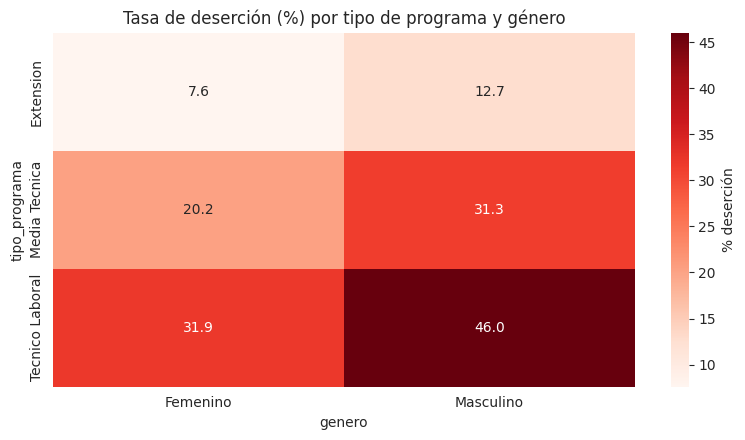

genero           Femenino  Masculino
tipo_programa                       
Extension             7.6       12.7
Media Tecnica        20.2       31.3
Tecnico Laboral      31.9       46.0


In [52]:
piv = d.pivot_table(index='tipo_programa', columns='genero',
                    values='desercion', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(piv.round(1), annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': '% deserción'})
ax.set_title('Tasa de deserción (%) por tipo de programa y género')
plt.tight_layout(); plt.show()

print(piv.round(1).to_string())

# **Conclusión**
El cruce confirma que ambos efectos **se acumulan**: dentro de cada tipo de programa los hombres
desertan más, y dentro de cada género el Técnico Laboral deserta más. La combinación de mayor riesgo
es **hombre en Técnico Laboral (46.0%)**, y la de menor riesgo **mujer en Extensión (7.6%)** una
diferencia de 38 puntos entre los extremos.

# **4. Correlación entre variables numéricas**

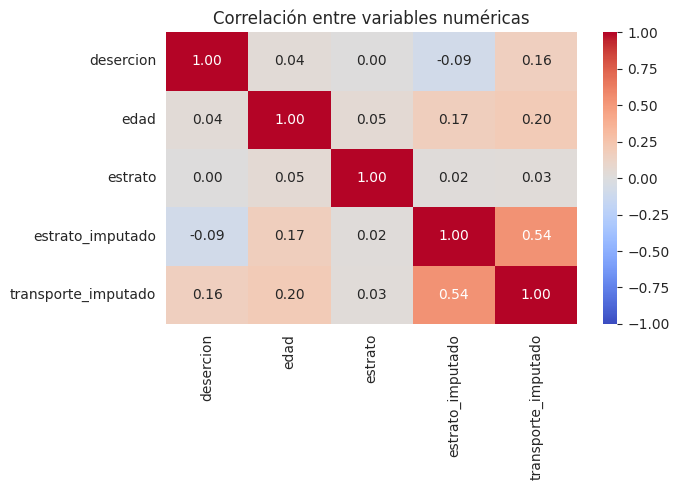

In [53]:
num_cols = [c for c in ['desercion', 'edad', 'estrato', 'estrato_imputado', 'transporte_imputado']
            if c in d.columns]
dnum = d[(d['edad'] >= 15) & (d['edad'] <= 80)][num_cols].astype(float)

plt.figure(figsize=(7, 5))
sns.heatmap(dnum.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables numéricas')
plt.tight_layout(); plt.show()

# **Conclusiones del EDA**

De 13,035 estudiantes, **el 35.2% desertó**. Por el desbalance, el modelo se evaluará con
**Recall, F1 y PR-AUC**, no con accuracy.

**Lo que más predice:** `programa` (100 pts de brecha), `nivel_de_formacion` (31),
`tipo_programa` (30), `eps` (29), `ocupacion` (24), `genero` (15) y `jornada` (15).
`estrato` y `zona` casi no discriminan, pero no se eliminan.

**Lo que no se puede usar:** `nivel` y `año de matrícula`. Parecen predictivas, pero son
consecuencia del desenlace, no causa

**Perfil de riesgo:** hombre de 26-35 años, en Técnico Laboral nocturno, afiliado a SISBEN
y residente fuera de Envigado.

**Límite del modelo:** el dataset solo tiene información del día de la matrícula, sin notas
ni asistencia. Servirá para priorizar mejor que al azar, no para predecir con alta precisión.